In [1]:
# 26.08.2026 - kontynuacja watku cykl-do-cyklu (patrz 20260824/20260824e.ipynb
# i 20260824/20260824.txt, "STAN NA KONIEC DNIA", punkty otwarte; oraz
# project_cycle_to_cycle_map.md w pamieci Claude'a).
#
# Krytyka Claude Opusa 5 (24.08, potwierdzona dla samej Moskwy w
# 20260824e.ipynb): wszystkie nasze skany indeksuja wynik POCZATKIEM okna
# (t0), a Fig.4 artykulu rysuje punkty w SRODKACH okien (t0+P/2, podpis
# figury wprost: "curve points located at the centers of the windows").
# Ten notebook rozszerza juz potwierdzona (dla Moskwy) poprawke na:
#
#   CZESC A: nachylenie "ukosnego pasa" (5 stacji reprezentatywnych, siatka
#            P_days 1675-4000, 20260823a.ipynb) - start vs srodek okna.
#            Falsyfikowalna predykcja Opusa: nachylenie powinno przesunac
#            sie WYRAZNIE w strone zera (pas bardziej pionowy).
#   CZESC B: wykresy w stylu Fig.4 artykulu (o co explicite prosil Homola
#            na spotkaniu 24.08) dla WSZYSTKICH dostepnych stacji (do 22)
#            per cykl sloneczny, w ukladzie SRODKA okna. Zastepuje heatmape
#            z 20260824a.ipynb - w ukladzie centrow P_days=1675 i P_days=
#            3350 maja RUZNE przesuniecie wzgledem wspolnej osi "lata od
#            startu cyklu", wiec wykres liniowy (rozne x dla roznych linii)
#            pasuje lepiej niz imshow (wymaga wspolnej siatki).
#   CZESC C: korelacja pochodnej LOWESS aktywnosci slonecznej z sila efektu
#            (20260823a.ipynb, "najsilniejszy wzorzec calego sledztwa" z
#            22.08) - pochodna probkowana w SRODKU okna zamiast w t0.
#            Falsyfikowalna predykcja Opusa: zaleznosc od P_days i
#            odwrocenie znaku (20260822g/h.ipynb) powinny zniknac.
#
# ZERO nowych obliczen NMDB/MC w tym notebooku - wylacznie ponowne
# przetworzenie juz zapisanych results/cycle_scan_*.csv i
# results/pgrid_scan_*.csv (jak wiekszosc notebookow 24.08). Bezpieczne,
# tanie, tylko-odczyt.
import glob
import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import linregress, spearmanr
from scipy.signal import find_peaks
from statsmodels.nonparametric.smoothers_lowess import lowess

RESULTS_DIR = "../results"
STATIONS_5 = ["mosc", "oulu", "athn", "hrms", "sopb"]

# Granice cykli identyczne jak 20260822g/h.ipynb, 20260823a/b.ipynb,
# 20260824a.ipynb (LOWESS frac=0.01 + find_peaks na SN_m_tot_V2.0.csv,
# obciete do zakresu katalogu EQ 1965-01-01..2025-01-31).
CYCLE_BOUNDS = {
    "cycle_1964": ("1965-01-01", "1976-02-01"),
    "cycle_1976": ("1976-02-01", "1986-05-01"),
    "cycle_1986": ("1986-05-01", "1996-06-01"),
    "cycle_1996": ("1996-06-01", "2008-11-01"),
    "cycle_2008": ("2008-11-01", "2019-09-01"),
    "cycle_2019_incomplete": ("2019-09-01", "2025-01-31"),
}
CYCLE_START = {c: pd.Timestamp(s) for c, (s, e) in CYCLE_BOUNDS.items()}
CYCLE_END = {c: pd.Timestamp(e) for c, (s, e) in CYCLE_BOUNDS.items()}
CYCLE_LENGTH_DAYS = {c: (CYCLE_END[c] - CYCLE_START[c]).days for c in CYCLE_BOUNDS}
FULL_CYCLES = [c for c in CYCLE_BOUNDS if c != "cycle_2019_incomplete"]  # 5 pelnych, jak 23.08a
for c, days in CYCLE_LENGTH_DAYS.items():
    print(f"{c}: {days} dni ({days/365.25:.2f} lat)")

cycle_1964: 4048 dni (11.08 lat)
cycle_1976: 3742 dni (10.25 lat)
cycle_1986: 3684 dni (10.09 lat)
cycle_1996: 4536 dni (12.42 lat)
cycle_2008: 3956 dni (10.83 lat)
cycle_2019_incomplete: 1979 dni (5.42 lat)


In [2]:
# CZESC A, krok 1: wczytanie cycle_scan_* + pgrid_scan_* dla 5 stacji
# reprezentatywnych, 5 PELNYCH cykli (bez cycle_2019_incomplete - brak dla
# niego danych na szerokiej siatce P_days, jak w 20260823a.ipynb) - kod
# identyczny jak tam.
FILENAME_RE_5 = re.compile(
    r"^(?P<prefix>cycle_scan|pgrid_scan)_(?P<station>[a-z]+)_(?P<cycle>cycle_\d{4})_P(?P<Pdays>\d+)_d(?P<d>\d+)\.csv$"
)


def parse_result_filename_5(path):
    m = FILENAME_RE_5.match(os.path.basename(path))
    if not m or m["station"] not in STATIONS_5 or m["cycle"] not in FULL_CYCLES:
        return None
    return dict(station=m["station"], cycle=m["cycle"], P_days=int(m["Pdays"]), d=int(m["d"]))


frames_5 = []
paths_5 = sorted(glob.glob(os.path.join(RESULTS_DIR, "cycle_scan_*.csv")) +
                  glob.glob(os.path.join(RESULTS_DIR, "pgrid_scan_*.csv")))
for path in paths_5:
    meta = parse_result_filename_5(path)
    if meta is None:
        continue
    df = pd.read_csv(path, usecols=["t0", "PPDF"], parse_dates=["t0"]).dropna(subset=["PPDF"])
    if len(df) == 0:
        continue
    df["station"] = meta["station"]
    df["cycle"] = meta["cycle"]
    df["P_days"] = meta["P_days"]
    df["d"] = meta["d"]
    frames_5.append(df)

all_candidates_5 = pd.concat(frames_5, ignore_index=True)
print(f"Wczytano {len(all_candidates_5)} wierszy z {len(frames_5)} plikow (5 stacji, siatka P_days, 5 pelnych cykli)")

Wczytano 1193732 wierszy z 336 plikow (5 stacji, siatka P_days, 5 pelnych cykli)


In [3]:
# CZESC A, krok 2: pozycja szczytu (lata-od-startu-cyklu) per (cykl, d,
# P_days), OSOBNO w ukladzie start-okna (center=False, identyczne jak
# 20260823a/24a.ipynb - kontrola zgodnosci) i srodek-okna (center=True,
# NOWE - pos = years_since_start_of_best_t0 + P_days/2 w latach).
# Przesuniecie o P_days/2 NIE zmienia KTORY t0 jest najlepszy (to ten sam
# argmax na medianie -log10(PPDF) po 5 stacjach) - zmienia tylko etykiete
# jego polozenia na osi czasu, dokladnie jak w 20260824e.ipynb dla samej
# Moskwy.
def ridge_points_for_cycle(cycle, d, center):
    cyc = all_candidates_5[(all_candidates_5["cycle"] == cycle) & (all_candidates_5["d"] == d)]
    t0_ref = pd.date_range(CYCLE_START[cycle], CYCLE_END[cycle], freq="24h")
    years_since_start = (t0_ref - CYCLE_START[cycle]).days / 365.25

    points = []
    for P_days, sub in cyc.groupby("P_days"):
        med_ppdf = sub.groupby("t0")["PPDF"].median().reindex(t0_ref)
        if med_ppdf.notna().sum() == 0:
            continue
        with np.errstate(divide="ignore"):
            neglog = -np.log10(np.clip(med_ppdf.to_numpy(dtype=float), 1e-300, None))
        if not np.isfinite(neglog).any():
            continue
        ti = np.nanargmax(neglog)
        offset_years = (P_days / 365.25 / 2) if center else 0.0
        points.append((P_days, years_since_start[ti] + offset_years, neglog[ti]))
    return pd.DataFrame(points, columns=["P_days", "peak_years_since_start", "peak_neglog10_ppdf"])


MIN_POINTS_FOR_FIT = 4  # ponizej tego regresja liniowa jest niewiele warta

ridge_rows = []
ridge_points_all = {}
for coord, center in [("start", False), ("center", True)]:
    for cycle in FULL_CYCLES:
        for d in (1, 5):
            pts = ridge_points_for_cycle(cycle, d, center)
            ridge_points_all[(coord, cycle, d)] = pts
            if len(pts) < MIN_POINTS_FOR_FIT:
                ridge_rows.append(dict(coord=coord, cycle=cycle, d=d, n_points=len(pts),
                                        slope_years_per_1000d=np.nan, r_value=np.nan, p_value=np.nan))
                continue
            fit = linregress(pts["P_days"], pts["peak_years_since_start"])
            ridge_rows.append(dict(
                coord=coord, cycle=cycle, d=d, n_points=len(pts),
                slope_years_per_1000d=fit.slope * 1000,
                r_value=fit.rvalue, p_value=fit.pvalue,
            ))

ridge_summary = pd.DataFrame(ridge_rows)
ridge_summary.to_csv(f"{RESULTS_DIR}/pgrid_ridge_slope_start_vs_center.csv", index=False)

# Tabela porownawcza obok siebie: nachylenie start vs center per (cykl, d).
compare = ridge_summary.pivot_table(index=["cycle", "d"], columns="coord",
                                     values="slope_years_per_1000d").reset_index()
compare["delta_center_minus_start"] = compare["center"] - compare["start"]
pd.set_option("display.width", 160)
print("Nachylenie 'ukosnego pasa' [lata/1000dni] - start vs srodek okna:")
print("(predykcja Opusa: 'center' powinno byc BLIZEJ ZERA niz 'start' - pas bardziej pionowy)")
print(compare.to_string(index=False))

Nachylenie 'ukosnego pasa' [lata/1000dni] - start vs srodek okna:
(predykcja Opusa: 'center' powinno byc BLIZEJ ZERA niz 'start' - pas bardziej pionowy)
     cycle  d    center     start  delta_center_minus_start
cycle_1964  1 -0.858466 -2.227391                  1.368925
cycle_1964  5  0.002526 -1.366400                  1.368925
cycle_1976  1 -0.548892 -1.917817                  1.368925
cycle_1976  5 -0.765416 -2.134342                  1.368925
cycle_1986  1 -0.796130 -2.165055                  1.368925
cycle_1986  5 -0.544469 -1.913394                  1.368925
cycle_1996  1 -2.175195 -3.544121                  1.368925
cycle_1996  5 -2.899644 -4.268569                  1.368925
cycle_2008  1  1.271987 -0.096938                  1.368925
cycle_2008  5 -1.514171 -2.883096                  1.368925


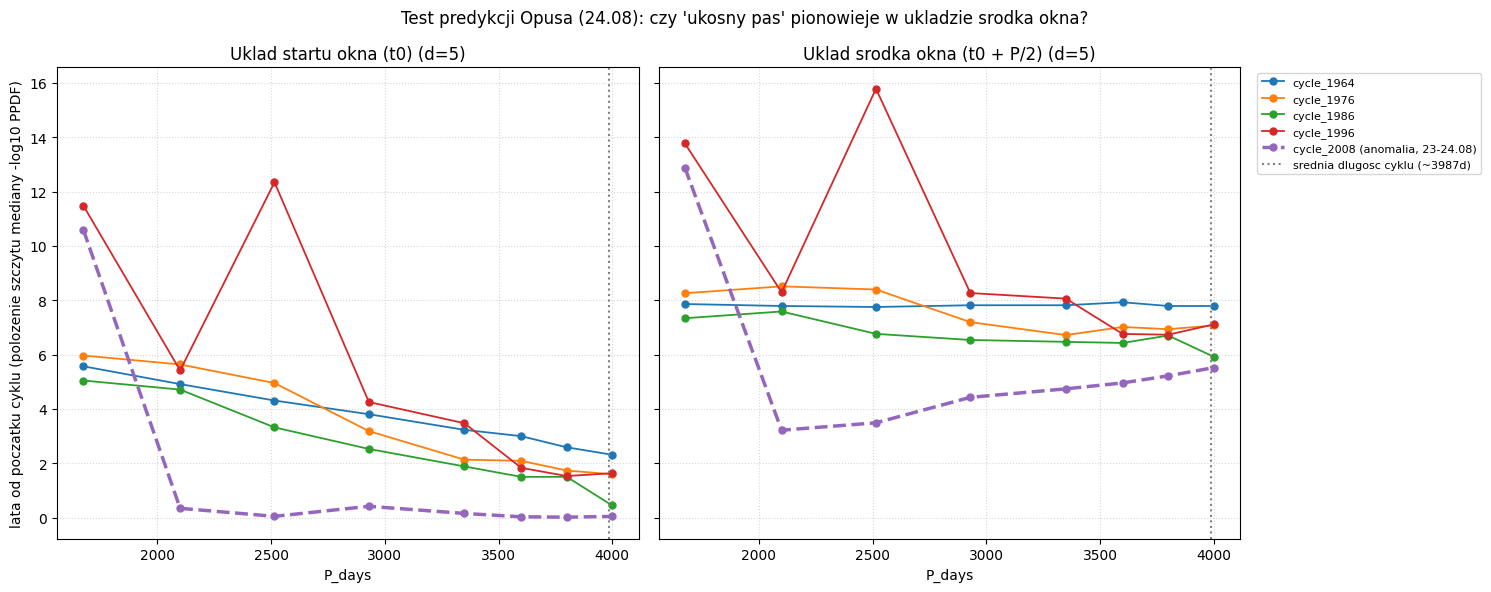

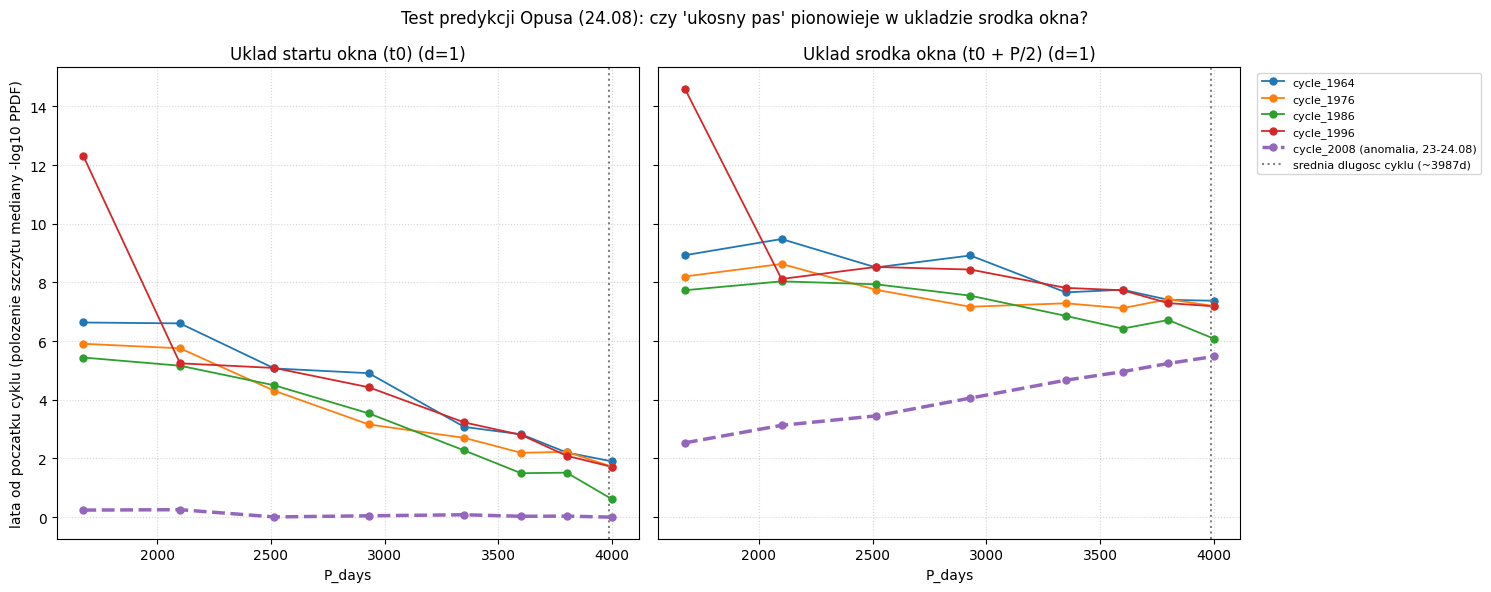

In [4]:
# CZESC A, krok 3: wizualizacja obok siebie - lewy panel = uklad startu
# okna (identyczny jak plot_ridge() w 20260824a.ipynb - kontrola), prawy
# panel = uklad srodka okna (NOWE). Jesli krytyka Opusa sie potwierdza,
# linie w prawym panelu powinny byc WYRAZNIE bardziej plaskie (blizej
# poziomych) niz w lewym.
def plot_ridge_comparison(d, save_suffix):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
    for ax, (coord, title) in zip(axes, [("start", "Uklad startu okna (t0)"),
                                          ("center", "Uklad srodka okna (t0 + P/2)")]):
        for cycle in FULL_CYCLES:
            pts = ridge_points_all[(coord, cycle, d)]
            if len(pts) == 0:
                continue
            is_2008 = cycle == "cycle_2008"
            ax.plot(pts["P_days"], pts["peak_years_since_start"], marker="o", ms=5,
                     lw=2.5 if is_2008 else 1.3, ls="--" if is_2008 else "-",
                     label=f"{cycle}{' (anomalia, 23-24.08)' if is_2008 else ''}")
        ax.axvline(3987, color="gray", ls=":", label="srednia dlugosc cyklu (~3987d)")
        ax.set_xlabel("P_days")
        ax.set_title(f"{title} (d={d})")
        ax.grid(ls=":", alpha=0.5)
    axes[0].set_ylabel("lata od poczatku cyklu (polozenie szczytu mediany -log10 PPDF)")
    axes[1].legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.suptitle("Test predykcji Opusa (24.08): czy 'ukosny pas' pionowieje w ukladzie srodka okna?")
    fig.tight_layout()
    fig.savefig(f"{RESULTS_DIR}/pgrid_ridge_slope_start_vs_center_{save_suffix}.png", dpi=120, bbox_inches="tight")
    plt.show()


plot_ridge_comparison(5, "d5")
plot_ridge_comparison(1, "d1")

In [5]:
# CZESC B, krok 1: wczytanie cycle_scan_*.csv dla WSZYSTKICH dostepnych
# stacji (do 22 - tylko P_days w {1675, 3350}, jedyne dostepne dla pelnego
# zestawu stacji, jak 20260824a.ipynb CZESC A), wszystkie 6 segmentow
# cykli (w tym cycle_2019_incomplete).
FILENAME_RE_22 = re.compile(
    r"^cycle_scan_(?P<station>[a-z0-9]+)_(?P<cycle>cycle_\d{4}(?:_incomplete)?)_P(?P<Pdays>\d+)_d(?P<d>\d+)\.csv$"
)
P_DAYS_ALLSTATIONS = [1675, 3350]


def parse_cycle_scan_filename(path):
    m = FILENAME_RE_22.match(os.path.basename(path))
    if not m or int(m["Pdays"]) not in P_DAYS_ALLSTATIONS or m["cycle"] not in CYCLE_BOUNDS:
        return None
    return dict(station=m["station"], cycle=m["cycle"], P_days=int(m["Pdays"]), d=int(m["d"]))


frames_22 = []
for path in sorted(glob.glob(os.path.join(RESULTS_DIR, "cycle_scan_*.csv"))):
    meta = parse_cycle_scan_filename(path)
    if meta is None:
        continue
    df = pd.read_csv(path, usecols=["t0", "PPDF"], parse_dates=["t0"]).dropna(subset=["PPDF"])
    if len(df) == 0:
        continue
    df["station"] = meta["station"]
    df["cycle"] = meta["cycle"]
    df["P_days"] = meta["P_days"]
    df["d"] = meta["d"]
    frames_22.append(df)

all_candidates_22 = pd.concat(frames_22, ignore_index=True)
print(f"Wczytano {len(all_candidates_22)} wierszy z {len(frames_22)} plikow (do 22 stacji)")

Wczytano 1206908 wierszy z 384 plikow (do 22 stacji)


In [6]:
# CZESC B, krok 2: plamy sloneczne wygladzone 13-miesiecznie (konwencja
# Fig.4 - "smoothed over 13 months", NIE LOWESS uzywany gdzie indziej do
# wykrywania granic cykli) + detekcja maksimow slonecznych do naniesienia
# jako pionowe linie odniesienia (test zdania artykulu "minima ~3 lata po
# maksimum" - jak w 20260824e.ipynb krok 5, tu rozszerzone na wszystkie
# cykle/stacje na raz).
sunspot = pd.read_csv("../data/SN_m_tot_V2.0.csv", sep=";")
sunspot.columns = [c.strip() for c in sunspot.columns]
sunspot["rok_norm"] = sunspot["rok_norm"].astype(float)
sunspot["sunspot"] = sunspot["sunspot"].astype(float)
sunspot = sunspot.sort_values("rok_norm")
sunspot["sunspot_smooth_13m"] = sunspot["sunspot"].rolling(13, center=True, min_periods=7).mean()

sunspot_valid = sunspot.dropna(subset=["sunspot_smooth_13m"])
max_idx, _ = find_peaks(sunspot_valid["sunspot_smooth_13m"].to_numpy(), distance=6 * 12)
solar_maxima_years = sunspot_valid["rok_norm"].to_numpy()[max_idx]
print(f"Wykryte maksima sloneczne (wygladzone 13m): {np.round(solar_maxima_years, 1)}")


def first_solar_max_after(year_start):
    later = solar_maxima_years[solar_maxima_years > year_start]
    return later.min() if len(later) else np.nan

Wykryte maksima sloneczne (wygladzone 13m): [1750.2 1761.4 1769.7 1778.4 1788.2 1794.5 1805.2 1816.7 1829.8 1837.3
 1848.1 1860.1 1870.8 1877.  1884.  1894.  1906.  1917.5 1928.2 1937.3
 1947.4 1958.2 1968.9 1980.  1989.5 2002.2 2014.3 2024.8]


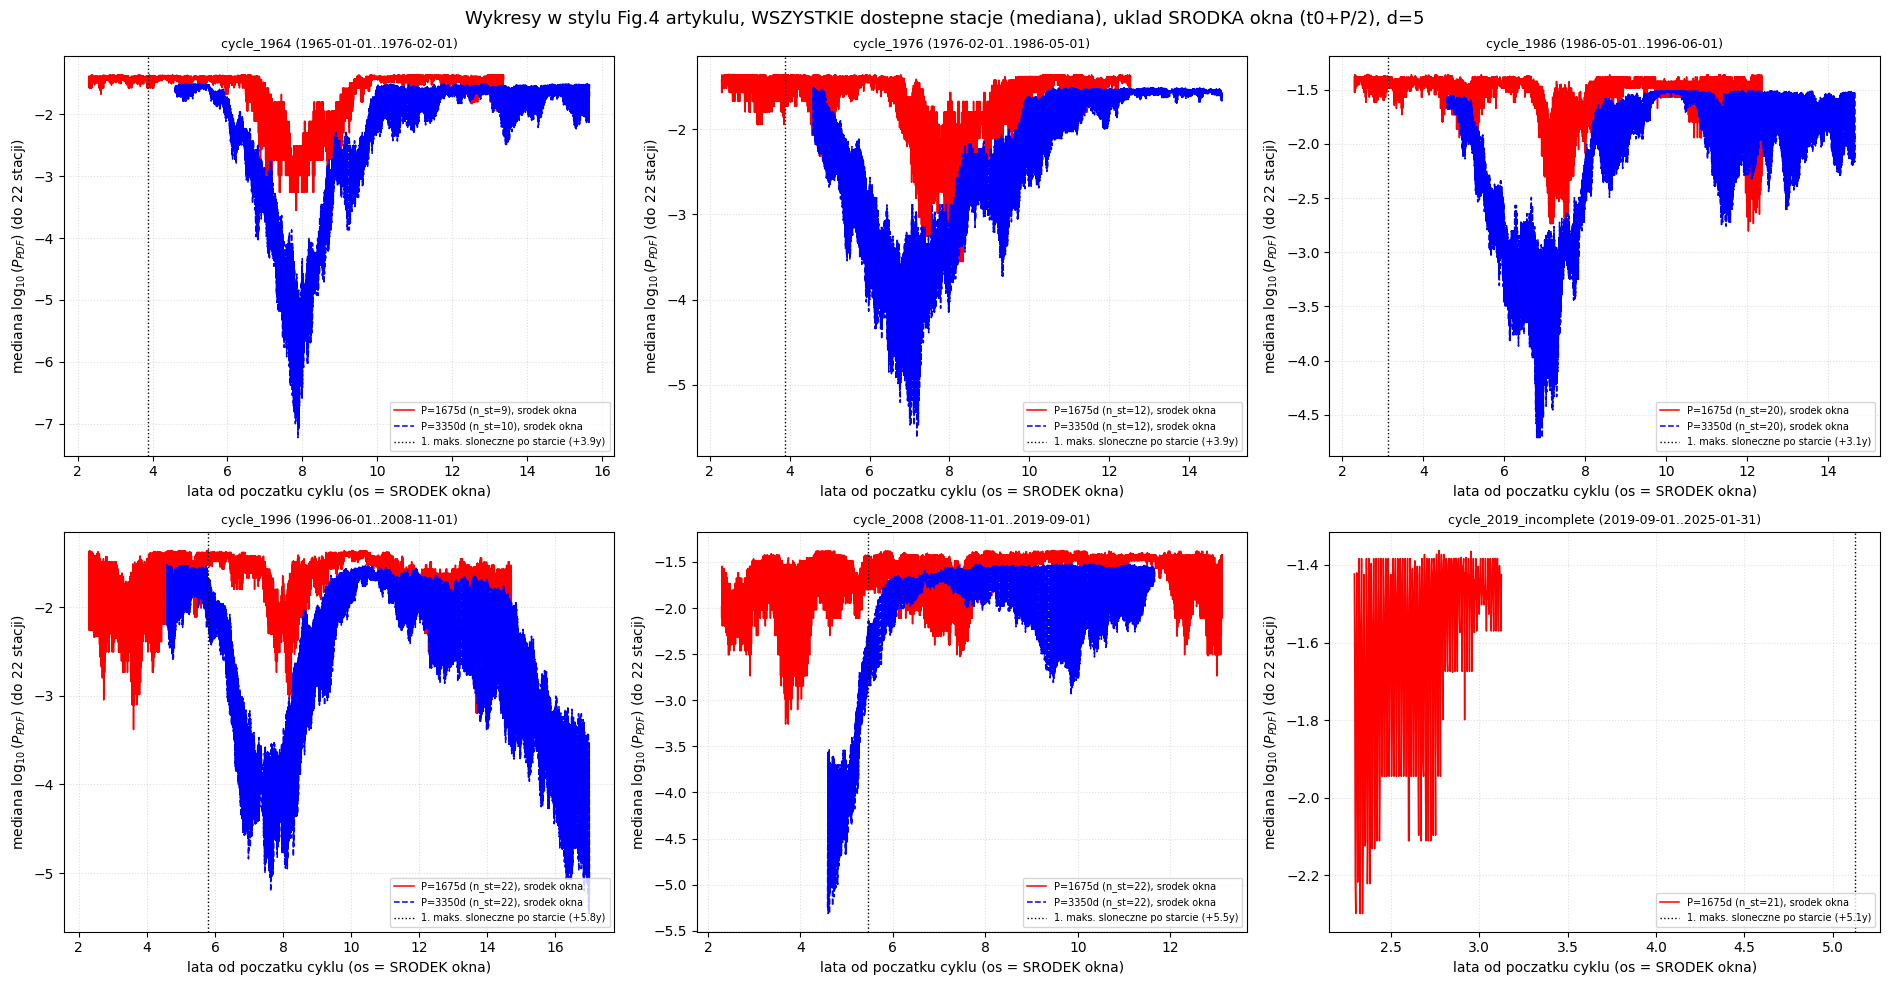

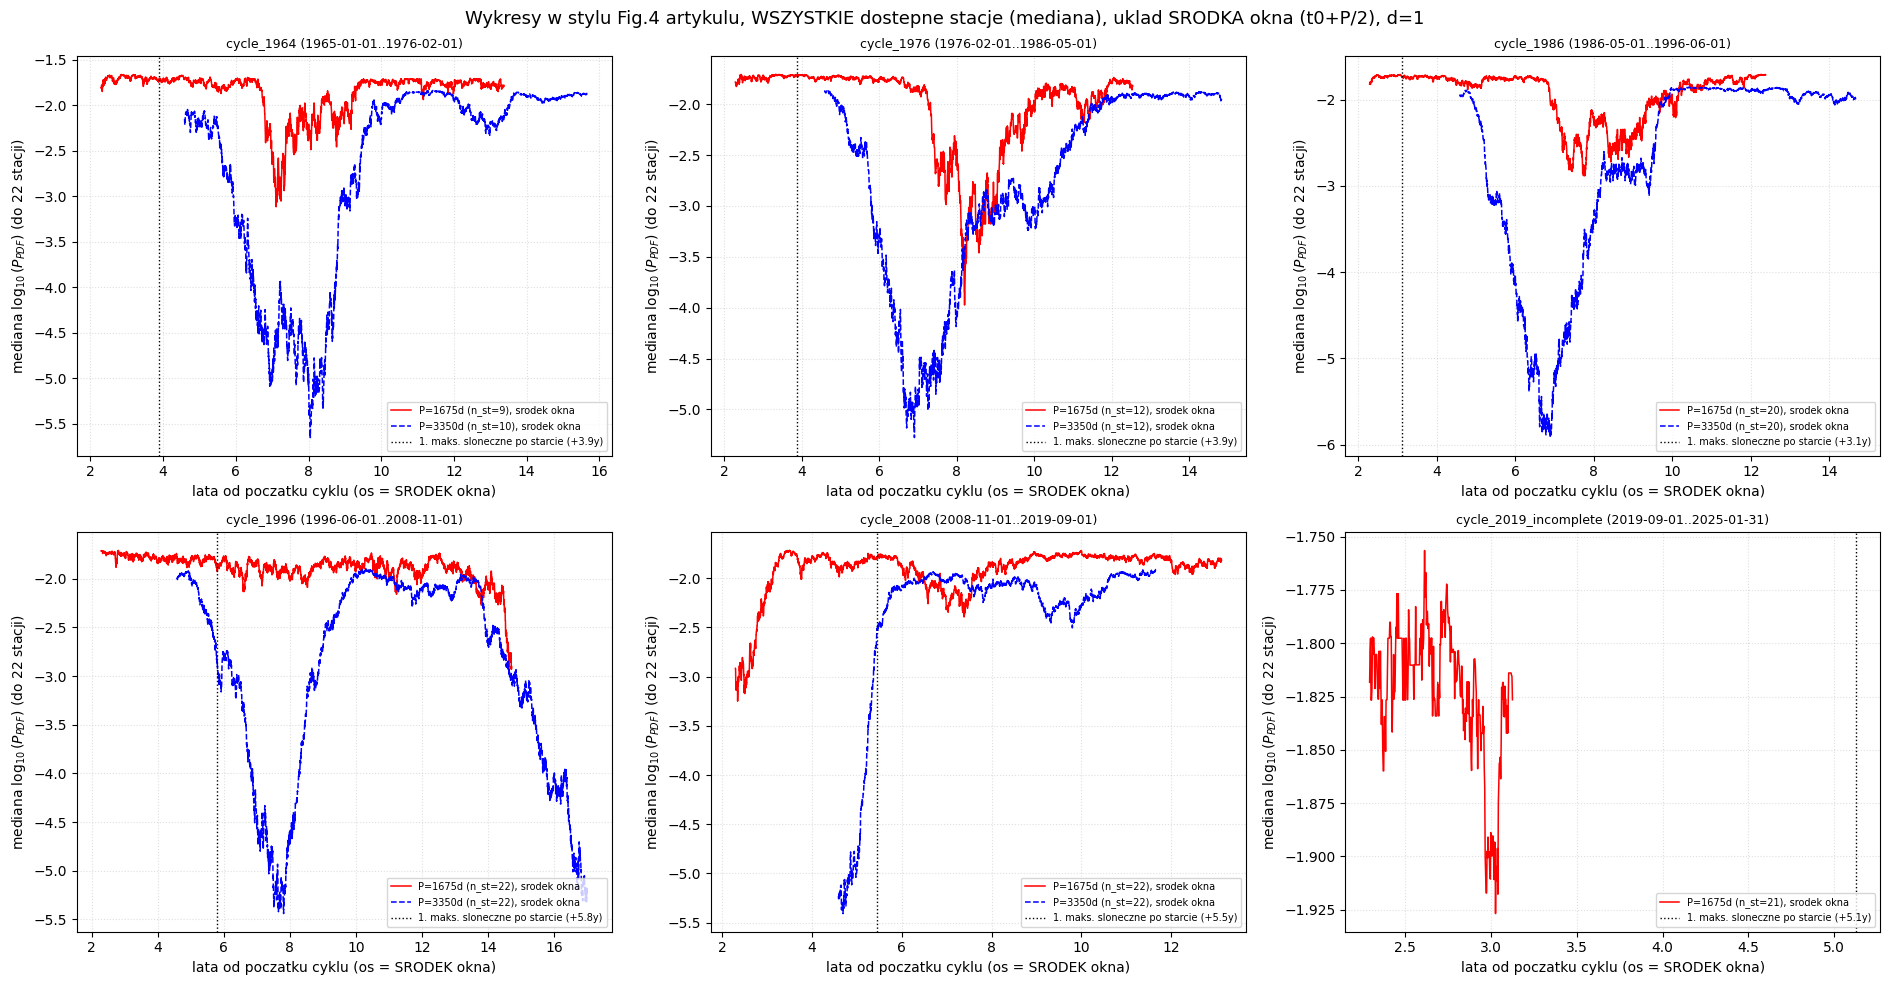

In [7]:
# CZESC B, krok 3: dla kazdego cyklu, wykres w stylu Fig.4 artykulu (o co
# explicite prosil Homola 24.08) - mediana log10(PPDF) po WSZYSTKICH
# dostepnych stacjach (do 22), P=1675 (czerwony) i P=3350 (niebieski),
# os X = lata od poczatku cyklu + P_days/2 (SRODEK okna, nie start) +
# pionowa linia = pierwsze maksimum sloneczne PO starcie cyklu (do
# wizualnej kontroli "~3 lata po maksimum").
def plot_fig4_style_by_cycle(d, save_suffix):
    cycles_order = list(CYCLE_BOUNDS.keys())
    fig, axes = plt.subplots(2, 3, figsize=(19, 10))
    for ax, cycle in zip(axes.flat, cycles_order):
        cyc = all_candidates_22[(all_candidates_22["cycle"] == cycle) & (all_candidates_22["d"] == d)]
        if len(cyc) == 0:
            ax.set_visible(False)
            continue
        t0_ref = pd.date_range(CYCLE_START[cycle], CYCLE_END[cycle], freq="24h")
        years_since_start = (t0_ref - CYCLE_START[cycle]).days / 365.25
        cycle_start_year = CYCLE_START[cycle].year + (CYCLE_START[cycle].dayofyear - 1) / 365.25

        for P_days, color, style in [(1675, "red", "-"), (3350, "blue", "--")]:
            sub = cyc[cyc["P_days"] == P_days]
            if len(sub) == 0:
                continue
            n_st = sub["station"].nunique()
            med_ppdf = sub.groupby("t0")["PPDF"].median().reindex(t0_ref)
            with np.errstate(divide="ignore"):
                log10_ppdf = np.log10(np.clip(med_ppdf.to_numpy(dtype=float), 1e-300, None))
            x_center = years_since_start + P_days / 365.25 / 2
            ax.plot(x_center, log10_ppdf, color=color, ls=style, lw=1.1,
                     label=f"P={P_days}d (n_st={n_st}), srodek okna")

        solar_max_year = first_solar_max_after(cycle_start_year)
        if np.isfinite(solar_max_year):
            ax.axvline(solar_max_year - cycle_start_year, color="black", lw=1.0, ls=":",
                        label=f"1. maks. sloneczne po starcie (+{solar_max_year - cycle_start_year:.1f}y)")

        ax.set_ylabel(r"mediana $\log_{10}(P_{PDF})$ (do 22 stacji)")
        ax.set_xlabel("lata od poczatku cyklu (os = SRODEK okna)")
        ax.set_title(f"{cycle} ({CYCLE_START[cycle].date()}..{CYCLE_END[cycle].date()})", fontsize=9)
        ax.grid(ls=":", alpha=0.4)
        ax.legend(fontsize=7, loc="lower right")

    for ax in axes.flat[len(cycles_order):]:
        ax.set_visible(False)
    fig.suptitle(
        f"Wykresy w stylu Fig.4 artykulu, WSZYSTKIE dostepne stacje (mediana), "
        f"uklad SRODKA okna (t0+P/2), d={d}",
        fontsize=13,
    )
    fig.tight_layout()
    fig.savefig(f"{RESULTS_DIR}/fig4_style_allstations_by_cycle_center_{save_suffix}.png",
                dpi=120, bbox_inches="tight")
    plt.show()


plot_fig4_style_by_cycle(5, "d5")
plot_fig4_style_by_cycle(1, "d1")

In [8]:
# CZESC C, krok 1: korelacja pochodnej LOWESS aktywnosci slonecznej z sila
# efektu (-log10 PPDF), jak w 20260823a.ipynb, ale pochodna probkowana w
# SRODKU okna (t0 + P_days/2) ROWNOLEGLE z t0 (start) - dla bezposredniego
# porownania na tych samych punktach. Falsyfikowalna predykcja Opusa:
# zaleznosc od P_days i odwrocenie znaku (20260822g/h.ipynb) powinny
# zniknac w wersji "center".
sn = pd.read_csv("../data/SN_m_tot_V2.0.csv", sep=";")
sn.columns = [c.strip() for c in sn.columns]
sn["date"] = pd.to_datetime(dict(year=sn["rok"], month=sn["miesiac"], day=1))
smoothed = lowess(sn["sunspot"].values, sn["rok_norm"].values, frac=0.01)[:, 1]
sn_derivative = np.gradient(smoothed, sn["rok_norm"].values)


def solar_derivative_at(dates):
    x = mdates.date2num(sn["date"].to_numpy())
    return np.interp(mdates.date2num(pd.DatetimeIndex(dates)), x, sn_derivative)


rows = []
for (station, cycle, P_days, d), g in all_candidates_5.groupby(["station", "cycle", "P_days", "d"]):
    if len(g) < 30:
        continue
    strength = -np.log10(np.clip(g["PPDF"].to_numpy(dtype=float), 1e-300, None))
    t0_center = g["t0"] + pd.to_timedelta(P_days / 2, unit="D")
    deriv_center = solar_derivative_at(t0_center.to_numpy())
    deriv_start = solar_derivative_at(g["t0"].to_numpy())
    rho_center, _ = spearmanr(deriv_center, strength)
    rho_start, _ = spearmanr(deriv_start, strength)
    rows.append(dict(
        station=station, cycle=cycle, P_days=P_days, d=d, n=len(g),
        P_frac=P_days / CYCLE_LENGTH_DAYS[cycle],
        spearman_rho_start=rho_start, spearman_rho_center=rho_center,
    ))

corr_by_cycle_df = pd.DataFrame(rows).sort_values(["cycle", "P_days", "d", "station"])
corr_by_cycle_df.to_csv(f"{RESULTS_DIR}/pgrid_solar_derivative_correlation_start_vs_center.csv", index=False)
print(f"{len(corr_by_cycle_df)} wierszy (stacja x cykl x P_days x d, n>=30)")

336 wierszy (stacja x cykl x P_days x d, n>=30)


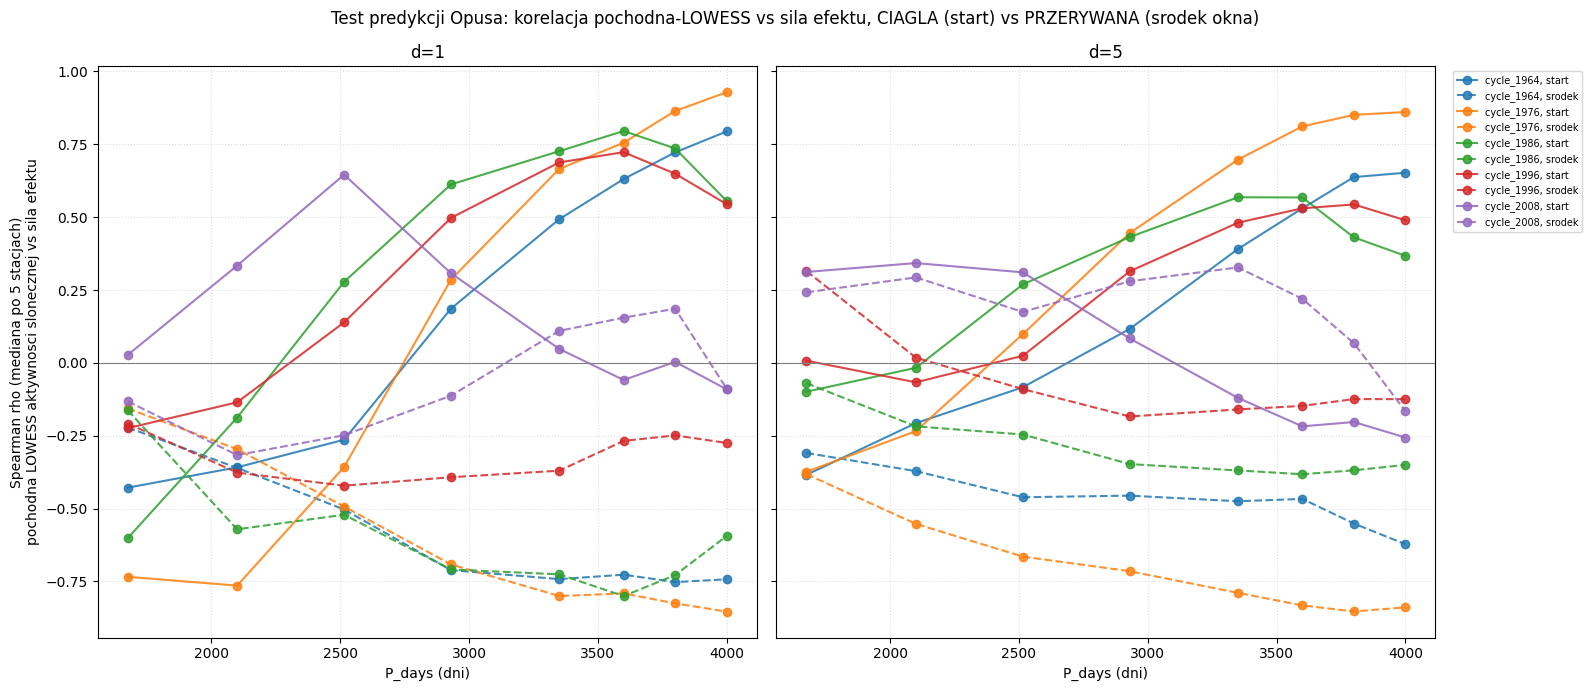

In [9]:
# CZESC C, krok 2: GLOWNY WYKRES porownawczy - mediana (po 5 stacjach) rho
# per cykl, linia CIAGLA = start okna (jak 20260823a.ipynb), linia
# PRZERYWANA tego samego koloru = srodek okna (NOWE). Jesli krytyka Opusa
# sie potwierdza, linie przerywane powinny byc WYRAZNIE PLASKIE (rho ~
# stale, bez zaleznosci od P_days i bez zmiany znaku) w porownaniu do
# ciaglych.
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
for ax, d in zip(axes, [1, 5]):
    sub_d = corr_by_cycle_df[corr_by_cycle_df["d"] == d]
    for cycle, g in sub_d.groupby("cycle"):
        med_start = g.groupby("P_days")["spearman_rho_start"].median().sort_index()
        med_center = g.groupby("P_days")["spearman_rho_center"].median().sort_index()
        line, = ax.plot(med_start.index, med_start.values, "o-", lw=1.5, alpha=0.85,
                          label=f"{cycle}, start")
        ax.plot(med_center.index, med_center.values, "o--", lw=1.5, alpha=0.85,
                 color=line.get_color(), label=f"{cycle}, srodek")
    ax.axhline(0, color="gray", lw=0.8)
    ax.set_xlabel("P_days (dni)")
    ax.set_title(f"d={d}")
    ax.grid(ls=":", alpha=0.4)
axes[0].set_ylabel("Spearman rho (mediana po 5 stacjach)\npochodna LOWESS aktywnosci slonecznej vs sila efektu")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
fig.suptitle("Test predykcji Opusa: korelacja pochodna-LOWESS vs sila efektu, CIAGLA (start) vs PRZERYWANA (srodek okna)")
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/pgrid_solar_derivative_correlation_start_vs_center.png", dpi=120, bbox_inches="tight")
plt.show()

In [10]:
# PODSUMOWANIE LICZBOWE (do dziennika 20260826.txt) - odpowiedz na
# falsyfikowalne predykcje Opusa wprost, liczbami:
print("=== CZESC A: nachylenie ukosnego pasa, start vs srodek okna ===")
print(compare.to_string(index=False))
print(f"\nSrednia |nachylenie| start:  {compare['start'].abs().mean():.2f} lat/1000dni")
print(f"Srednia |nachylenie| center: {compare['center'].abs().mean():.2f} lat/1000dni")

print("\n=== CZESC C: korelacja pochodna-LOWESS vs sila efektu, rozpietosc median rho po P_days ===")
for d in (1, 5):
    sub_d = corr_by_cycle_df[corr_by_cycle_df["d"] == d]
    med_start_by_p = sub_d.groupby("P_days")["spearman_rho_start"].median()
    med_center_by_p = sub_d.groupby("P_days")["spearman_rho_center"].median()
    print(f"d={d}: start  rho zakres [{med_start_by_p.min():.2f}, {med_start_by_p.max():.2f}] "
          f"(rozpietosc {med_start_by_p.max() - med_start_by_p.min():.2f})")
    print(f"      center rho zakres [{med_center_by_p.min():.2f}, {med_center_by_p.max():.2f}] "
          f"(rozpietosc {med_center_by_p.max() - med_center_by_p.min():.2f})")

print("\nPredykcja Opusa POTWIERDZONA jesli:")
print("  (A) 'center' nachylenie WYRAZNIE blizsze 0 niz 'start';")
print("  (C) 'center' rozpietosc median rho WYRAZNIE mniejsza niz 'start' (linia ~plaska).")
print("Panele cyklu 2008 w CZESCI B (wykresy Fig.4-style) do obejrzenia recznie:")
print("czy w ukladzie srodka okna nadal wyglada 'plasko' (potwierdzenie anomalii z 23-24.08),")
print("czy pojawia sie ten sam periodyczny wzorzec co w pozostalych 4 cyklach.")

=== CZESC A: nachylenie ukosnego pasa, start vs srodek okna ===
     cycle  d    center     start  delta_center_minus_start
cycle_1964  1 -0.858466 -2.227391                  1.368925
cycle_1964  5  0.002526 -1.366400                  1.368925
cycle_1976  1 -0.548892 -1.917817                  1.368925
cycle_1976  5 -0.765416 -2.134342                  1.368925
cycle_1986  1 -0.796130 -2.165055                  1.368925
cycle_1986  5 -0.544469 -1.913394                  1.368925
cycle_1996  1 -2.175195 -3.544121                  1.368925
cycle_1996  5 -2.899644 -4.268569                  1.368925
cycle_2008  1  1.271987 -0.096938                  1.368925
cycle_2008  5 -1.514171 -2.883096                  1.368925

Srednia |nachylenie| start:  2.25 lat/1000dni
Srednia |nachylenie| center: 1.14 lat/1000dni

=== CZESC C: korelacja pochodna-LOWESS vs sila efektu, rozpietosc median rho po P_days ===
d=1: start  rho zakres [-0.34, 0.71] (rozpietosc 1.05)
      center rho zakres [-0.59, -0.1